# 05b — Classical Baselines (Full Data, Sensitivity Run)
**Project:** Quantum Machine Learning for Physiological Stress Classification
**Author:** Kenza Qribis

---

## Purpose
`05_classical_baselines.ipynb` trains the classical models on a stratified subsample
(150 windows/class/fold) to keep the comparison fair against the quantum models in
`07`-`08`, which are computationally constrained to small inputs.

The CNN (`06`) and hybrid CNN-QNN (`09`) baselines, however, are trained on the **full**
dataset — they have no such constraint. That means the subsampled classical numbers in
`05` are *not* a fair comparison point against the CNN/hybrid results.

This notebook reruns the same classical models (Logistic Regression, SVM RBF, Random
Forest), same LOSO protocol, same tuned hyperparameter grids as `05` — but on the full
training fold each time, with no subsampling. This is a **sensitivity check**: it shows
whether the 150/class subsampling in `05` cost the classical models accuracy, and gives
the number that should actually be placed next to the CNN/hybrid results in any
full-data comparison or significance test.

## What changed vs. `05`
- No `stratified_subsample()` call — every LOSO fold trains on all windows from the
  other subjects (same set the CNN/hybrid models see).
- Everything else is identical: same pipelines, same hyperparameter grids, same inner
  `StratifiedKFold(5)` search, same `class_weight='balanced'`, same median imputation
  fit on train only.

## Output
- `results/output_data/classical_baselines_full_per_fold.csv`
- `results/output_data/classical_baselines_full_summary.csv`
- `results/output_data/classical_subsample_vs_full.csv` — side-by-side F1 comparison
  against the `05` subsampled results, per task/model.

---


## 0. Configuration

In [2]:
import os, json, time, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime

from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler, RobustScaler
from sklearn.model_selection import GridSearchCV, StratifiedKFold
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, confusion_matrix
)

warnings.filterwarnings('ignore')

RESULTS_ROOT    = os.path.join('..', 'results')
PLOTS_DIR       = os.path.join(RESULTS_ROOT, 'plots', '05b_classical_baselines_full')
LOGS_DIR        = os.path.join(RESULTS_ROOT, 'logs')
OUTPUT_DATA_DIR = os.path.join(RESULTS_ROOT, 'output_data')
for d in [PLOTS_DIR, LOGS_DIR, OUTPUT_DATA_DIR]:
    os.makedirs(d, exist_ok=True)

ECG_FEATURE_PREFIXES = ['ecg_']
RANDOM_STATE = 42

# Inner CV for hyperparameter search (same as 05)
INNER_CV = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

plt.rcParams['figure.dpi'] = 110
plt.rcParams['font.size']  = 11
sns.set_style('whitegrid')

print('Configuration ready — FULL DATA run (no subsampling).')
print(f'  Random state      : {RANDOM_STATE}')
print(f'  Inner CV (tuning) : StratifiedKFold(5)')
print(f'  Plots dir          : {os.path.abspath(PLOTS_DIR)}')


Configuration ready — FULL DATA run (no subsampling).
  Random state      : 42
  Inner CV (tuning) : StratifiedKFold(5)
  Plots dir          : c:\Users\vPro\OneDrive\Desktop\kenza\research\Applied-Research\results\plots\05b_classical_baselines_full


## 1. Load Datasets
Same feature CSVs produced by notebooks `02`/`04` (via `05`'s DREAMER-ratings fix if needed).

In [3]:
df_wesad_bin = pd.read_csv(
    os.path.join(OUTPUT_DATA_DIR, 'wesad_features_binary.csv'))
df_wesad_3cl = pd.read_csv(
    os.path.join(OUTPUT_DATA_DIR, 'wesad_features_3class.csv'))
wesad_feat_cols = json.load(
    open(os.path.join(OUTPUT_DATA_DIR, 'feature_columns.json')))

df_dreamer = pd.read_csv(
    os.path.join(OUTPUT_DATA_DIR, 'dreamer_features_binary.csv'))
dreamer_all_feats = json.load(
    open(os.path.join(OUTPUT_DATA_DIR, 'dreamer_feature_columns.json')))
dreamer_eeg_feats = [c for c in dreamer_all_feats
                     if not any(c.startswith(p) for p in ECG_FEATURE_PREFIXES)]

assert len(df_dreamer) > 0 and not df_dreamer['arousal_binary'].isna().all(), (
    "DREAMER ratings look broken — run the '1b. Fix DREAMER Ratings' cell in "
    "05_classical_baselines.ipynb first, which rewrites dreamer_features_binary.csv."
)

print('=== Datasets Loaded ===')
print(f'WESAD binary  : {df_wesad_bin.shape}  features={len(wesad_feat_cols)}')
print(f'WESAD 3-class : {df_wesad_3cl.shape}')
print(f'DREAMER binary: {df_dreamer.shape}  EEG features={len(dreamer_eeg_feats)}')

wesad_subjects   = sorted(df_wesad_bin['subject_id'].unique())
dreamer_subjects = sorted(df_dreamer['subject_id'].unique())
print(f'\nWESAD subjects  : {wesad_subjects}')
print(f'DREAMER subjects: {dreamer_subjects}')


=== Datasets Loaded ===
WESAD binary  : (883, 30)  features=26
WESAD 3-class : (1049, 30)
DREAMER binary: (414, 146)  EEG features=134

WESAD subjects  : [np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9), np.int64(10), np.int64(11), np.int64(13), np.int64(14), np.int64(15), np.int64(16), np.int64(17)]
DREAMER subjects: [np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9), np.int64(10), np.int64(11), np.int64(12), np.int64(13), np.int64(14), np.int64(15), np.int64(16), np.int64(17), np.int64(18), np.int64(19), np.int64(20), np.int64(21), np.int64(22), np.int64(23)]


## 2. Model Utilities (identical pipelines/grids to `05`, no subsampling step)

In [4]:
def compute_metrics(y_true, y_pred, average='macro'):
    return {
        'accuracy' : float(accuracy_score(y_true, y_pred)),
        'precision': float(precision_score(y_true, y_pred, average=average, zero_division=0)),
        'recall'   : float(recall_score(y_true, y_pred, average=average, zero_division=0)),
        'f1'       : float(f1_score(y_true, y_pred, average=average, zero_division=0)),
    }


def get_tuned_pipelines():
    # Identical to 05_classical_baselines.ipynb — keep grids in sync if you edit one.
    return {
        'Logistic Regression': (
            Pipeline([
                ('scaler', StandardScaler()),
                ('clf', LogisticRegression(max_iter=1000, class_weight='balanced',
                                            random_state=RANDOM_STATE)),
            ]),
            {'clf__C': [0.01, 0.1, 1, 10, 100]}
        ),
        'SVM (RBF)': (
            Pipeline([
                ('scaler', StandardScaler()),
                ('clf', SVC(kernel='rbf', class_weight='balanced',
                            probability=True, random_state=RANDOM_STATE)),
            ]),
            {
                'scaler': [StandardScaler(), RobustScaler()],
                'clf__C': [0.1, 1, 10, 100],
                'clf__gamma': ['scale', 'auto', 0.01, 0.1, 1],
            }
        ),
        'Random Forest': (
            Pipeline([
                ('scaler', StandardScaler()),
                ('clf', RandomForestClassifier(class_weight='balanced',
                                                random_state=RANDOM_STATE, n_jobs=-1)),
            ]),
            {
                'clf__n_estimators': [100, 200, 300],
                'clf__max_depth': [None, 5, 10, 20],
            }
        ),
    }


def run_loso_full(df, feature_cols, label_col, subject_col,
                   task_name='task', average='macro'):
    """
    Same LOSO + nested-GridSearchCV protocol as run_loso_tuned() in 05, but the
    inner search and final fit see the FULL training fold (all windows from the
    14/22 other subjects) — no stratified_subsample() call. This matches what
    06_cnn_baseline.ipynb and 09_hybrid_cnn_qnn.ipynb train on.
    """
    subjects = sorted(df[subject_col].unique())
    classes  = sorted(df[label_col].unique())
    n_cls    = len(classes)

    fold_rows   = []
    model_names = list(get_tuned_pipelines().keys())
    cm_dict     = {name: np.zeros((n_cls, n_cls), dtype=int) for name in model_names}

    print(f'\n=== {task_name} — LOSO tuned, FULL DATA ({len(subjects)} folds) ===')
    print(f'    Train : all windows for the other {len(subjects)-1} subjects')
    print(f'    Test  : all windows for held-out subject')
    print(f'    Inner CV : StratifiedKFold(5) for hyperparameter search')

    for fold_i, test_sid in enumerate(subjects):
        train_mask = df[subject_col] != test_sid
        test_mask  = df[subject_col] == test_sid

        X_train = df.loc[train_mask, feature_cols].values.astype(float)
        y_train = df.loc[train_mask, label_col].values
        X_test  = df.loc[test_mask,  feature_cols].values.astype(float)
        y_test  = df.loc[test_mask,  label_col].values

        imputer = SimpleImputer(strategy='median')
        X_train = imputer.fit_transform(X_train)
        X_test  = imputer.transform(X_test)

        # NOTE: no stratified_subsample() here — this is the only functional
        # difference from run_loso_tuned() in 05_classical_baselines.ipynb.

        for model_name, (pipeline, param_grid) in get_tuned_pipelines().items():
            t0 = time.time()
            search = GridSearchCV(pipeline, param_grid, cv=INNER_CV,
                                   scoring='f1_macro', n_jobs=-1)
            search.fit(X_train, y_train)
            train_time = time.time() - t0

            t0 = time.time()
            y_pred = search.predict(X_test)
            test_time = time.time() - t0

            metrics = compute_metrics(y_test, y_pred, average=average)
            cm      = confusion_matrix(y_test, y_pred, labels=classes)
            cm_dict[model_name] += cm

            best_params = {k: (v.__class__.__name__ if hasattr(v, 'fit') else v)
                           for k, v in search.best_params_.items()}

            fold_rows.append({
                'task'         : task_name,
                'model'        : model_name,
                'fold'         : fold_i + 1,
                'test_subject' : int(test_sid),
                'train_size'   : len(y_train),
                'test_size'    : len(y_test),
                'train_time'   : round(train_time, 4),
                'test_time'    : round(test_time, 4),
                'best_params'  : json.dumps(best_params),
                **metrics
            })

        if (fold_i + 1) % 5 == 0 or fold_i == 0:
            print(f'  Fold {fold_i+1:2d}/{len(subjects)} - '
                  f'test=S{test_sid}  train={len(y_train)}  test={len(y_test)}')

    return pd.DataFrame(fold_rows), cm_dict

print('Full-data utilities defined.')


Full-data utilities defined.


## 3. WESAD — Binary Task (baseline vs stress)

In [5]:
results_wb_full, cm_wb_full = run_loso_full(
    df           = df_wesad_bin,
    feature_cols = wesad_feat_cols,
    label_col    = 'label_encoded',
    subject_col  = 'subject_id',
    task_name    = 'WESAD_binary',
)
print('\n=== WESAD Binary (full data) - Mean Metrics ===')
print(results_wb_full.groupby('model')[['accuracy','precision','recall','f1',
                                         'train_time','test_time']]
      .mean().round(4).to_string())



=== WESAD_binary — LOSO tuned, FULL DATA (15 folds) ===
    Train : all windows for the other 14 subjects
    Test  : all windows for held-out subject
    Inner CV : StratifiedKFold(5) for hyperparameter search
  Fold  1/15 - test=S2  train=827  test=56
  Fold  5/15 - test=S6  train=824  test=59
  Fold 10/15 - test=S11  train=824  test=59
  Fold 15/15 - test=S17  train=822  test=61

=== WESAD Binary (full data) - Mean Metrics ===
                     accuracy  precision  recall      f1  train_time  test_time
model                                                                          
Logistic Regression    0.8649     0.8907  0.8620  0.8371      0.9224     0.0013
Random Forest          0.9181     0.9323  0.8986  0.9000     17.6037     0.1263
SVM (RBF)              0.8465     0.8283  0.8228  0.7966      8.7252     0.0036


## 4. WESAD — 3-Class Task (baseline / stress / amusement)

In [6]:
results_w3_full, cm_w3_full = run_loso_full(
    df           = df_wesad_3cl,
    feature_cols = wesad_feat_cols,
    label_col    = 'label_encoded',
    subject_col  = 'subject_id',
    task_name    = 'WESAD_3class',
)
print('\n=== WESAD 3-Class (full data) - Mean Metrics ===')
print(results_w3_full.groupby('model')[['accuracy','precision','recall','f1',
                                         'train_time','test_time']]
      .mean().round(4).to_string())



=== WESAD_3class — LOSO tuned, FULL DATA (15 folds) ===
    Train : all windows for the other 14 subjects
    Test  : all windows for held-out subject
    Inner CV : StratifiedKFold(5) for hyperparameter search
  Fold  1/15 - test=S2  train=982  test=67
  Fold  5/15 - test=S6  train=979  test=70
  Fold 10/15 - test=S11  train=979  test=70
  Fold 15/15 - test=S17  train=977  test=72

=== WESAD 3-Class (full data) - Mean Metrics ===
                     accuracy  precision  recall      f1  train_time  test_time
model                                                                          
Logistic Regression    0.6469     0.6231  0.6590  0.5750      0.9209     0.0014
Random Forest          0.7361     0.6660  0.6354  0.6130     20.6142     0.1615
SVM (RBF)              0.6414     0.5969  0.5972  0.5253     18.4142     0.0087


## 5. DREAMER — Binary Task (EEG features only)

In [7]:
results_db_full, cm_db_full = run_loso_full(
    df           = df_dreamer,
    feature_cols = dreamer_eeg_feats,
    label_col    = 'arousal_binary',
    subject_col  = 'subject_id',
    task_name    = 'DREAMER_binary_EEG',
)
print('\n=== DREAMER Binary EEG (full data) - Mean Metrics ===')
print(results_db_full.groupby('model')[['accuracy','precision','recall','f1',
                                         'train_time','test_time']]
      .mean().round(4).to_string())



=== DREAMER_binary_EEG — LOSO tuned, FULL DATA (23 folds) ===
    Train : all windows for the other 22 subjects
    Test  : all windows for held-out subject
    Inner CV : StratifiedKFold(5) for hyperparameter search
  Fold  1/23 - test=S1  train=396  test=18
  Fold  5/23 - test=S5  train=396  test=18
  Fold 10/23 - test=S10  train=396  test=18
  Fold 15/23 - test=S15  train=396  test=18
  Fold 20/23 - test=S20  train=396  test=18

=== DREAMER Binary EEG (full data) - Mean Metrics ===
                     accuracy  precision  recall      f1  train_time  test_time
model                                                                          
Logistic Regression    0.5145     0.5187  0.5077  0.4855      0.7141     0.0013
Random Forest          0.5193     0.5118  0.5207  0.4634     18.1311     0.1339
SVM (RBF)              0.5217     0.5022  0.5005  0.4629      7.2025     0.0042


## 6. Results Summary Table

In [8]:
all_results_full = pd.concat(
    [results_wb_full, results_w3_full, results_db_full], ignore_index=True)

summary_full = (
    all_results_full
    .groupby(['task','model'])
    .agg(
        accuracy_mean  = ('accuracy',   'mean'),
        accuracy_std   = ('accuracy',   'std'),
        precision_mean = ('precision',  'mean'),
        recall_mean    = ('recall',     'mean'),
        f1_mean        = ('f1',         'mean'),
        f1_std         = ('f1',         'std'),
        train_time_mean= ('train_time', 'mean'),
        test_time_mean = ('test_time',  'mean'),
    )
    .round(4)
    .reset_index()
)

print('=== CLASSICAL BASELINES - FULL DATA - SUMMARY ===')
print(summary_full.to_string(index=False))

p = os.path.join(OUTPUT_DATA_DIR, 'classical_baselines_full_summary.csv')
summary_full.to_csv(p, index=False)
print(f'\nSaved: {p}')

p2 = os.path.join(OUTPUT_DATA_DIR, 'classical_baselines_full_per_fold.csv')
all_results_full.to_csv(p2, index=False)
print(f'Saved: {p2}')


=== CLASSICAL BASELINES - FULL DATA - SUMMARY ===
              task               model  accuracy_mean  accuracy_std  precision_mean  recall_mean  f1_mean  f1_std  train_time_mean  test_time_mean
DREAMER_binary_EEG Logistic Regression         0.5145        0.1591          0.5187       0.5077   0.4855  0.1571           0.7141          0.0013
DREAMER_binary_EEG       Random Forest         0.5193        0.1260          0.5118       0.5207   0.4634  0.1193          18.1311          0.1339
DREAMER_binary_EEG           SVM (RBF)         0.5217        0.1095          0.5022       0.5005   0.4629  0.0953           7.2025          0.0042
      WESAD_3class Logistic Regression         0.6469        0.1649          0.6231       0.6590   0.5750  0.1636           0.9209          0.0014
      WESAD_3class       Random Forest         0.7361        0.1584          0.6660       0.6354   0.6130  0.1644          20.6142          0.1615
      WESAD_3class           SVM (RBF)         0.6414        0.1475 

## 7. Subsample vs. Full-Data Comparison
Loads the `05` subsampled summary (if it has already been run) and lines it up
against this notebook's full-data summary — this is the actual "sensitivity" result:
did the 150/class subsampling in `05` cost the classical models accuracy?

In [9]:
subsample_path = os.path.join(OUTPUT_DATA_DIR, 'classical_baselines_summary.csv')

if os.path.exists(subsample_path):
    summary_sub = pd.read_csv(subsample_path)
    summary_sub = summary_sub[['task','model','f1_mean','f1_std','accuracy_mean']]
    summary_sub = summary_sub.rename(columns={
        'f1_mean':'f1_mean_subsampled', 'f1_std':'f1_std_subsampled',
        'accuracy_mean':'accuracy_mean_subsampled'})

    summary_full_cmp = summary_full[['task','model','f1_mean','f1_std','accuracy_mean']]
    summary_full_cmp = summary_full_cmp.rename(columns={
        'f1_mean':'f1_mean_full', 'f1_std':'f1_std_full',
        'accuracy_mean':'accuracy_mean_full'})

    cmp = summary_sub.merge(summary_full_cmp, on=['task','model'], how='outer')
    cmp['f1_delta_full_minus_subsampled'] = (
        cmp['f1_mean_full'] - cmp['f1_mean_subsampled']).round(4)

    print('=== Subsampled (05) vs. Full Data (05b) — F1 (macro) ===')
    print(cmp.to_string(index=False))

    p = os.path.join(OUTPUT_DATA_DIR, 'classical_subsample_vs_full.csv')
    cmp.to_csv(p, index=False)
    print(f'\nSaved: {p}')
else:
    print(f'{subsample_path} not found — run 05_classical_baselines.ipynb first '
          'to get the subsampled numbers for this comparison.')


=== Subsampled (05) vs. Full Data (05b) — F1 (macro) ===
              task               model  f1_mean_subsampled  f1_std_subsampled  accuracy_mean_subsampled  f1_mean_full  f1_std_full  accuracy_mean_full  f1_delta_full_minus_subsampled
DREAMER_binary_EEG Logistic Regression              0.4336             0.1138                    0.4686        0.4855       0.1571              0.5145                          0.0519
DREAMER_binary_EEG       Random Forest              0.4664             0.1411                    0.5097        0.4634       0.1193              0.5193                         -0.0030
DREAMER_binary_EEG           SVM (RBF)              0.4859             0.1097                    0.5242        0.4629       0.0953              0.5217                         -0.0230
      WESAD_3class Logistic Regression              0.5724             0.1748                    0.6376        0.5750       0.1636              0.6469                          0.0026
      WESAD_3class       Ran

## 8. Performance Comparison Plot (full data)

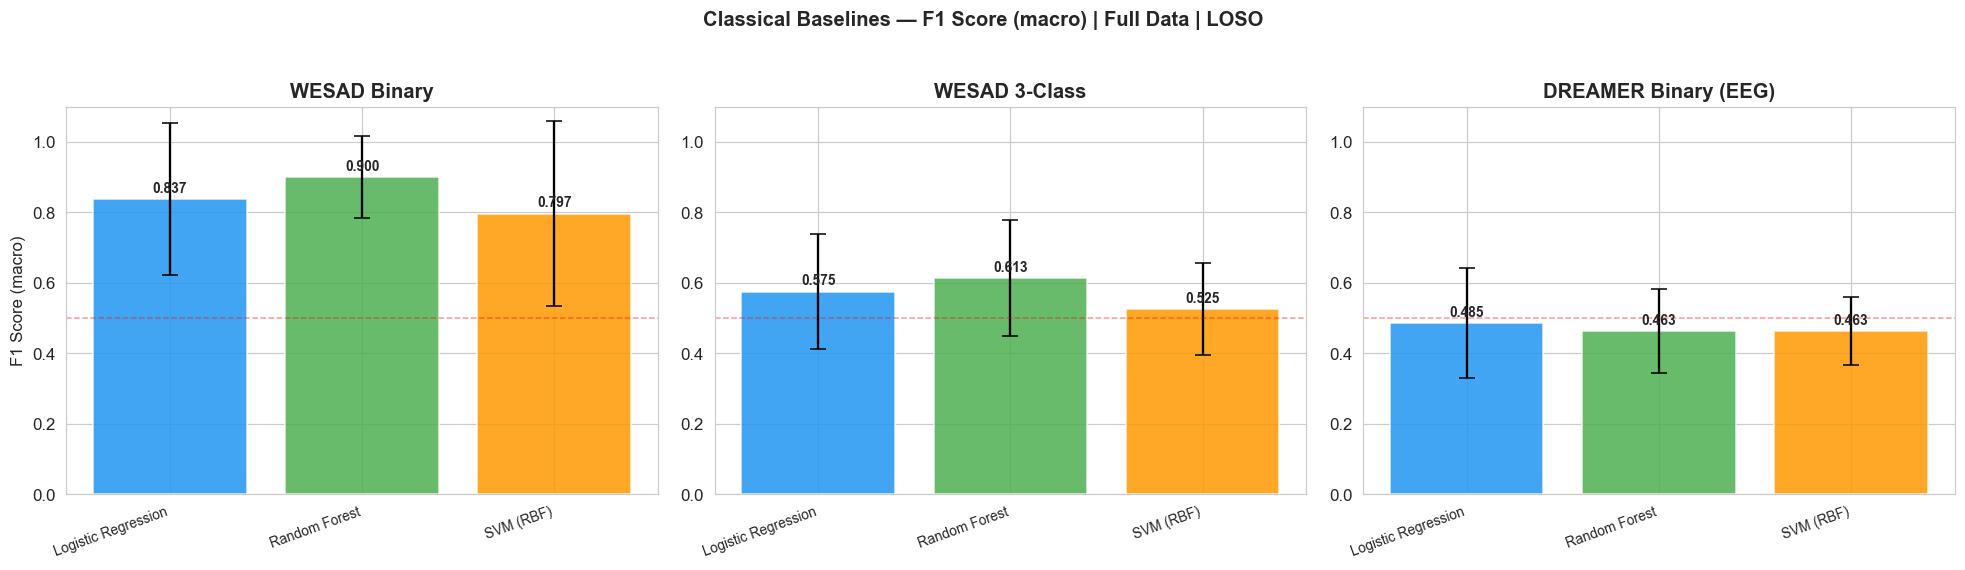

Saved: ..\results\plots\05b_classical_baselines_full\classical_full_f1_comparison.png


In [10]:
tasks = [
    ('WESAD_binary',      'WESAD Binary'),
    ('WESAD_3class',      'WESAD 3-Class'),
    ('DREAMER_binary_EEG','DREAMER Binary (EEG)'),
]
model_colors = {
    'Logistic Regression': '#2196F3',
    'SVM (RBF)'          : '#FF9800',
    'Random Forest'      : '#4CAF50',
}

fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=False)

for ax, (task_key, task_label) in zip(axes, tasks):
    td      = summary_full[summary_full['task'] == task_key]
    models  = td['model'].tolist()
    f1_m    = td['f1_mean'].tolist()
    f1_s    = td['f1_std'].tolist()
    colors  = [model_colors.get(m, 'gray') for m in models]
    bars    = ax.bar(models, f1_m, color=colors, alpha=0.85,
                     yerr=f1_s, capsize=5, edgecolor='white')
    for bar, val in zip(bars, f1_m):
        ax.text(bar.get_x() + bar.get_width()/2,
                bar.get_height() + 0.01,
                f'{val:.3f}', ha='center', va='bottom',
                fontsize=9, fontweight='bold')
    ax.set_title(task_label, fontweight='bold')
    ax.set_ylabel('F1 Score (macro)' if ax == axes[0] else '')
    ax.set_ylim(0, 1.1)
    ax.set_xticklabels(models, rotation=20, ha='right', fontsize=9)
    ax.axhline(0.5, color='red', linestyle='--', lw=1, alpha=0.4, label='chance')

plt.suptitle('Classical Baselines — F1 Score (macro) | Full Data | LOSO',
             fontweight='bold', y=1.03)
plt.tight_layout()
p = os.path.join(PLOTS_DIR, 'classical_full_f1_comparison.png')
plt.savefig(p, bbox_inches='tight'); plt.show()
print(f'Saved: {p}')


## 9. Summary Log

In [11]:
summary_dict = {
    'notebook'   : '05b_classical_baselines_full',
    'timestamp'  : datetime.now().isoformat(),
    'subsampling': 'none — full training fold used at every LOSO iteration',
    'purpose'    : ('Sensitivity check + fair comparison point for the full-data '
                     'CNN (06) and hybrid CNN-QNN (09) baselines.'),
    'models'     : ['Logistic Regression', 'SVM (RBF)', 'Random Forest'],
    'tasks'      : ['WESAD_binary', 'WESAD_3class', 'DREAMER_binary_EEG'],
    'evaluation' : 'Leave-One-Subject-Out (LOSO)',
    'results'    : {}
}

for _, row in summary_full.iterrows():
    key = f"{row['task']}|{row['model']}"
    summary_dict['results'][key] = {
        'accuracy_mean': row['accuracy_mean'],
        'f1_mean'      : row['f1_mean'],
        'f1_std'       : row['f1_std'],
        'train_time_s' : row['train_time_mean'],
    }

p = os.path.join(LOGS_DIR, '05b_classical_baselines_full_summary.json')
with open(p, 'w') as f:
    json.dump(summary_dict, f, indent=2)

print('=' * 60)
print('CLASSICAL BASELINES (FULL DATA) COMPLETE')
print('=' * 60)
print(json.dumps(summary_dict, indent=2))
print(f'\nLog saved: {p}')


CLASSICAL BASELINES (FULL DATA) COMPLETE
{
  "notebook": "05b_classical_baselines_full",
  "timestamp": "2026-09-28T21:04:27.349504",
  "subsampling": "none \u2014 full training fold used at every LOSO iteration",
  "purpose": "Sensitivity check + fair comparison point for the full-data CNN (06) and hybrid CNN-QNN (09) baselines.",
  "models": [
    "Logistic Regression",
    "SVM (RBF)",
    "Random Forest"
  ],
  "tasks": [
    "WESAD_binary",
    "WESAD_3class",
    "DREAMER_binary_EEG"
  ],
  "evaluation": "Leave-One-Subject-Out (LOSO)",
  "results": {
    "DREAMER_binary_EEG|Logistic Regression": {
      "accuracy_mean": 0.5145,
      "f1_mean": 0.4855,
      "f1_std": 0.1571,
      "train_time_s": 0.7141
    },
    "DREAMER_binary_EEG|Random Forest": {
      "accuracy_mean": 0.5193,
      "f1_mean": 0.4634,
      "f1_std": 0.1193,
      "train_time_s": 18.1311
    },
    "DREAMER_binary_EEG|SVM (RBF)": {
      "accuracy_mean": 0.5217,
      "f1_mean": 0.4629,
      "f1_std": 0.09